<div style="background: #86d1f1ff; border-radius: 5px; padding: 1rem; margin-bottom: 1rem">
<img src="https://store.utec.edu.pe/files/Recursos/logo-utec-h.png" alt="Banner" width="150" />   
<div style="font-weight: bold; color: #434549ff; float: right "><u style="font-size: 28px;">Base de Datos II</u> <br />
<span style="float:right"> Profesor Heider Sanchez</span> <br /> 
<span style="float:right">  2026 - 1 </span>   
</div> </div>

# Laboratorio 8.1: Procesamiento de Textos y Bag of Words

> **Prof. Heider Sanchez**  

##  Introducción
Este laboratorio tiene como objetivo el análisis y búsqueda de documentos textuales utilizando procesamiento de lenguaje natural (NLP) y una base de datos PostgreSQL. Se trabajará paso a paso desde la extracción de los textos hasta la aplicación búsquedas booleanas.


### Objetivos
- Configurar la tabla en PostgreSQL y carga de datos.
- Desde Python leer los textos desde PostgreSQL.
- Realizar el procesamiento de textos: convertir a minúscula, tokenización, stopwords, stemming y frecuencia de términos.
- Almacenar los Bag of Words en la base de datos en formato JSON.
- Realizar búsquedas de documentos similares a una consulta booleana (conectores AND, OR y AND-NOT).


### Requisitos previos

- Tener instalado PostgreSQL en su computadora (ultima versión)
- Tener instalado las siguientes dependencias en Python:

    ```bash
    pip install psycopg2-binary nltk scikit-learn pandas
    ```

- Opcionalmente descargar los recursos de NLTK:

    ```python
    import nltk
    nltk.download('punkt')
    ```


## 1. (2 puntos) Configurar la tabla en PostgreSQL y carga de datos


### Crear las tablas

Crear la tabla en PostgreSQL para almacenar los textos de noticias y el bag of words:

```sql
CREATE TABLE noticias (
    id SERIAL PRIMARY KEY,
    url TEXT,
    contenido TEXT,
    categoria VARCHAR(50),
    bag_of_words JSONB
);
```

Además, crear una tabla para almacenar los stopwords

```sql
CREATE TABLE stopwords (
    id SERIAL PRIMARY KEY,
    word TEXT UNIQUE NOT NULL
);
```

### Carga de datos en PostgreSQL

Proceder a cargar el dataset de noticias `news_es.csv` y el dataset de stopwords `stoplist_es.txt`.

### Leer desde PostgreSQL con Python

Completar la función para conectarte a PostgreSQL y leer los datos:

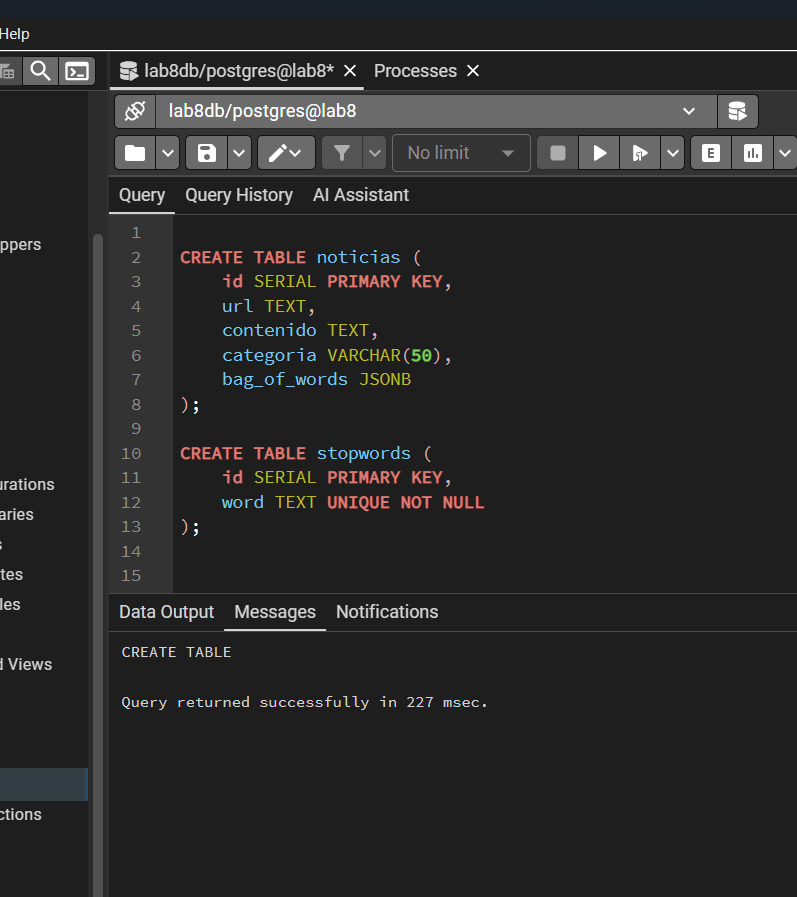
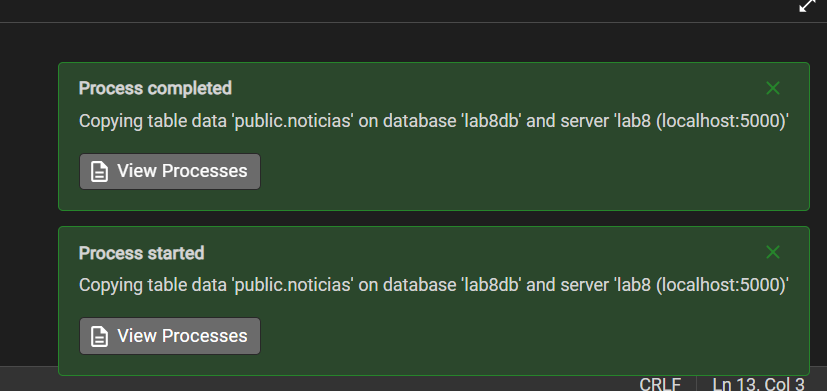
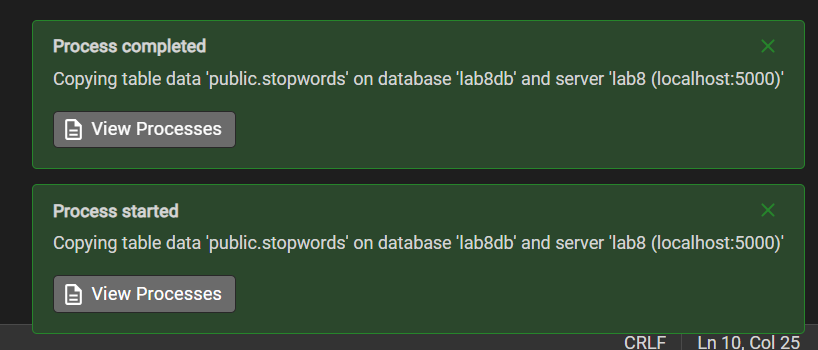
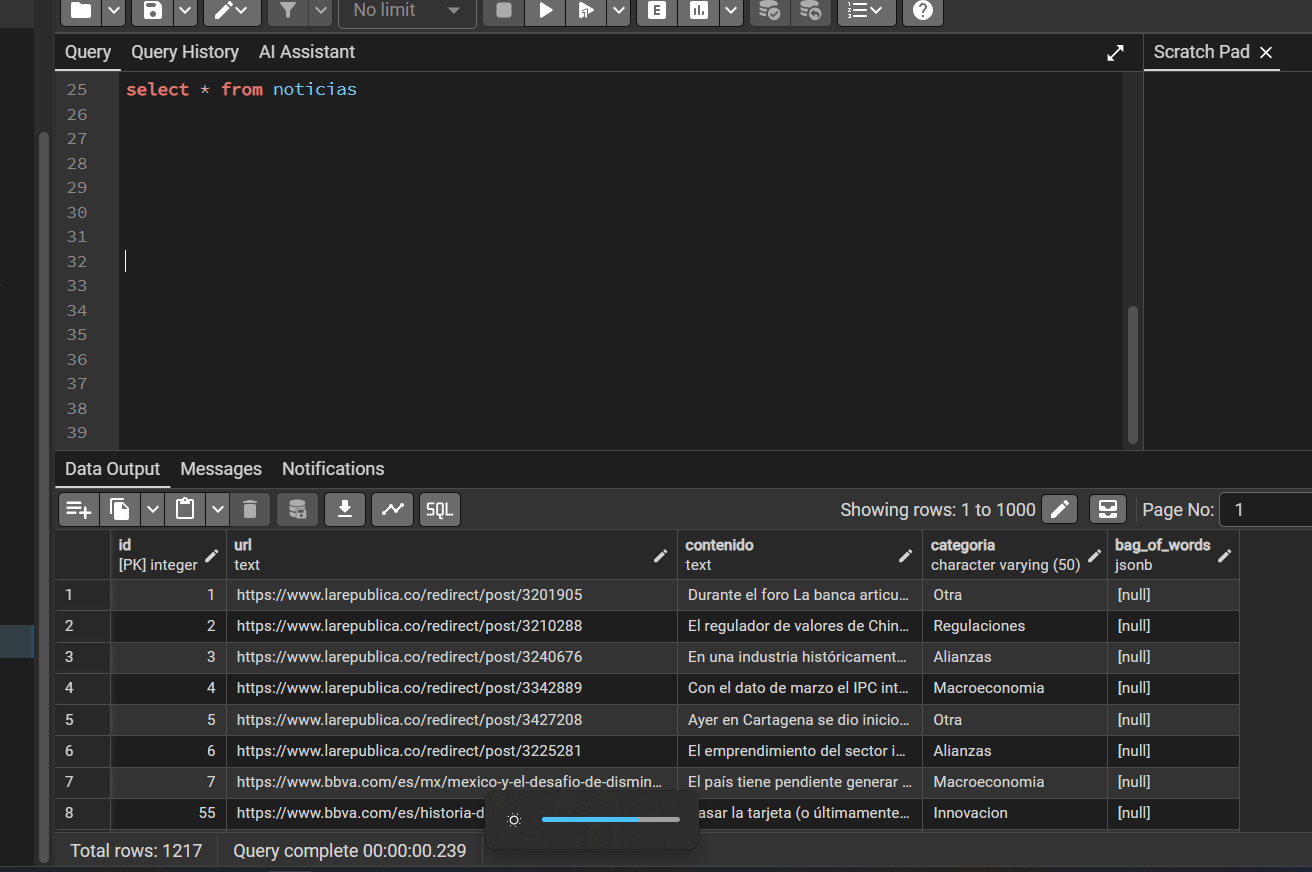
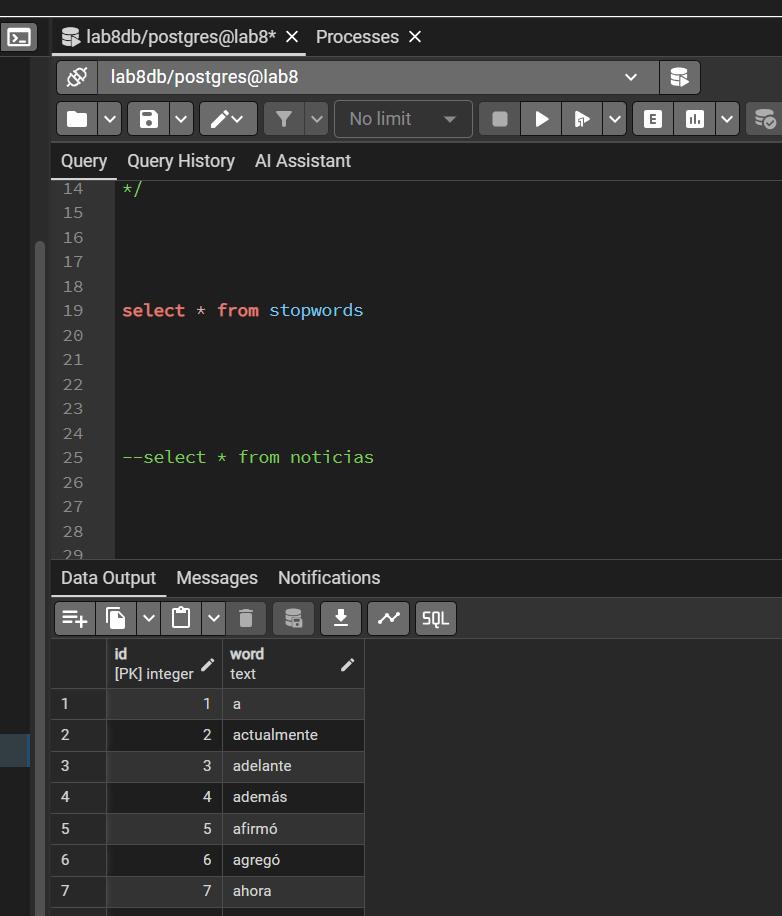

In [2]:
pip install pandas psycopg2-binary nltk scikit-learn

  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached regex-2026.5.9-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)
Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached regex-2026.5.9-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (801 kB)
Using cached scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64

In [ ]:
import psycopg2
import pandas as pd

def connect_db():
    conn = psycopg2.connect(
        dbname="lab8",
        user="postgres",
        password="postgres",
        host="127.0.0.1",
        port="5432"
    )
    return conn

def fetch_data():
    conn = connect_db()
    query = "SELECT id, contenido FROM noticias;"
    df = pd.read_sql(query, conn)
    conn.close()
    return df

noticias_df = fetch_data()
print(f"¡Carga completada! Se descargaron {len(noticias_df)} filas.")

¡Carga completada! Se descargaron 1217 filas.


/tmp/ipykernel_7511/2145523452.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


## 2. (4 puntos) Preprocesamiento de texto

Implementar la función `preprocess` que reciba un texto y realice los siguiente:
- Convertir el texto a minuscula.
- Tokenización.
- Eliminación de stopwords
- Stemming (raíz de las palabras)

In [2]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/vssz/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /home/vssz/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
def fetch_stopwords():
    conn = connect_db()
    query = "SELECT word FROM stopwords;"
    df_words = pd.read_sql(query, conn)
    conn.close()
    return set(df_words['word'].tolist())

stopwords_es = fetch_stopwords()
print(f"¡Listo! Se cargaron {len(stopwords_es)} stopwords desde la base de datos.")

¡Listo! Se cargaron 607 stopwords desde la base de datos.


/tmp/ipykernel_10190/280612892.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_words = pd.read_sql(query, conn)


In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

# Inicializamos el stemmer en español para reducir las palabras a su raíz léxica
stemmer = SnowballStemmer('spanish')

def preprocess(text):
    """
    Recibe un texto crudo y realiza: minúsculas, tokenización, 
    eliminación de stopwords y stemming.
    """
    if not text:
        return []
    
    # Convertir el texto a minúscula
    text = text.lower() 
    
    # Tokenizar las palabras
    tokens = word_tokenize(text) 
    
    # Eliminación de stopwords, números y símbolos
    cleaned_tokens = [
        token for token in tokens 
        if token.isalpha() and token not in stopwords_es
    ] 
    
    # Stemming (reducir las palabras a su raíz)
    stemmed_tokens = [stemmer.stem(token) for token in cleaned_tokens] 
    
    return stemmed_tokens




In [ ]:
print("--- Prueba de Preprocesamiento ---")
print(preprocess("¡Hola! Esto es una prueba, con números 123 y símbolos #@$%$. ¿Funcionará bien?")) 

--- Prueba de Preprocesamiento ---
['prueb', 'numer', 'simbol']


Luego, implementar una función para calcular la frecuencia de términos:

In [6]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer

def compute_bow(text):
    """
    Recibe un texto, lo preprocesa y calcula la frecuencia de 
    cada término (Bag of Words) retornando un diccionario.
    """
    # Obtenemos la lista de raíces (tokens) ya procesada
    tokens = preprocess(text)
    
    # Calculamos la frecuencia de términos
    bow = {}
    for token in tokens:
        bow[token] = bow.get(token, 0) + 1
        
    return bow




In [7]:
compute_bow("Esta es una prueba con prueba y más prueba. ¡Prueba!. Programadores programadores programando.")

{'prueb': 3, 'program': 3}

## 3. (3 puntos) Actualizar la base de datos con los Bag of Words

Guardar el resultado del Bag of Words en la columna `bag_of_words` de la tabla:

In [12]:
import json
import psycopg2

def update_bow_in_db(dataframe):
    # Conexión a PostgreSQL
    conn = connect_db()
    cursor = conn.cursor()

    # Recorrer el dataframe
    for _, row in dataframe.iterrows():

        noticia_id = row["id"]

        # Generar Bag of Words
        bow = compute_bow(row["contenido"])

        # Convertir a JSON
        bow_json = json.dumps(bow)

        # Actualizar en PostgreSQL
        cursor.execute("""
            UPDATE noticias
            SET bag_of_words = %s
            WHERE id = %s
        """, (bow_json, noticia_id))

    # Guardar cambios
    conn.commit()

    print("Bag of Words actualizado correctamente.")

    cursor.close()
    conn.close()


update_bow_in_db(noticias_df)

Bag of Words actualizado correctamente.


In [13]:
def fetch_data_bow():
    # Conexión a PostgreSQL
    conn = connect_db()
    cursor = conn.cursor()
    # Obtener primeras 10 filas
    cursor.execute("""
        SELECT *
        FROM noticias
        LIMIT 10
    """)

    rows = cursor.fetchall()

    # Mostrar resultados
    for row in rows:
        print(row)

    cursor.close()
    conn.close()


fetch_data_bow()

(500, 'https://www.larepublica.co/redirect/post/3184324', 'Durante la última semana el precio del dólar subió 1655 luego de que cerró 3589 por encima de la TRM en la última jornada recuperando así las pérdidas de días anteriores.De hecho hasta ayer la moneda estadounidense había descendido 1934 sin embargo este viernes cerró a 3.625 en promedio.Esta fuerte recuperación se dio luego de que se conociera que el Índice de Precios al Consumidor IPC de Estados Unidos subió 06 el segundo mayor avance en más de una década.Aunque distorsionado por la pandemia el IPC saltó 5 respecto al año anterior la mayor ganancia anual desde agosto de 2008 según datos del Departamento de Trabajo de Estados Unidos.Las ganancias fueron impulsadas en gran parte por el retroceso de los precios en categorías asociadas con una reapertura más amplia de la economía. El informe del IPC mostró un crecimiento constante en los costos de vehículos usados muebles para el hogar pasajes aéreos y vestuario.El aumento en auto

## 4. (8 puntos) Consulta booleana con filtrado por keywords

Antes de aplicar el filtrado desde Python, es importante entender cómo funciona la consulta de una clave dentro de una columna JSONB en PostgreSQL. 

### Ejemplo consulta SQL en JSON:

```sql
SELECT * FROM noticias WHERE bag_of_words ? 'keyword';
```

Esta consulta selecciona todos los registros en los que el `bag_of_words` (formato JSONB) contiene una clave igual a `'keyword'`. El operador `?` verifica la existencia de una clave dentro de un JSON.

### Consulta booleana 
Implementar una función que permita parsear una consulta textual con conectores AND, OR y AND-NOT y con ello se aplique el filtro correspondiente directamente desde la base de datos. 


In [22]:
import pandas as pd

def apply_boolean_query(query_str):
    tokens = query_str.split()
    sql_conditions = []
    params = []
    last_was_word = False
    
    for token in tokens:
        if token in ["AND", "OR", "AND-NOT"]:
            if token == "AND":
                sql_conditions.append("AND")
            elif token == "OR":
                sql_conditions.append("OR")
            elif token == "AND-NOT":
                sql_conditions.append("AND NOT")
            
            last_was_word = False
            
        # Si es una palabra clave
        else:
            # Si la palabra anterior no fue un conector, asumimos un AND
            if last_was_word:
                sql_conditions.append("AND")
                
            tokens_limpios = preprocess(token)
            
            if len(tokens_limpios) > 0:
                token_final = tokens_limpios[0]
            else:
                token_final = "termino_ignorado"
                
            sql_conditions.append("bag_of_words ? %s")
            params.append(token_final)
            
            last_was_word = True
            
    # Unimos todo
    where_clause = " ".join(sql_conditions)
    sql_query = f"SELECT id, url, contenido, categoria FROM noticias WHERE {where_clause};"
    

    conn = connect_db()
    cursor = conn.cursor()    
    cursor.execute(sql_query, tuple(params))
    records = cursor.fetchall()
    if not records:
        cursor.close()
        conn.close()
        return pd.DataFrame()
        
    columnas = [desc[0] for desc in cursor.description]
    df = pd.DataFrame(records, columns=columnas)
    cursor.close()
    conn.close()
    
    return df

In [35]:
preprocess("criptomonedas OR bitcoin OR regulación")

['criptomoned', 'or', 'bitcoin', 'or', 'regul']

### Pruebas funcionales

Realizar al menos 8 pruebas funcionales con mas de dos keywords de consulta:

In [36]:
test_queries = [
    "transformación AND sostenible", # Consulta con AND
    "México OR Perú",  # Consulta con OR
    "México AND-NOT Perú",  # Consulta con AND-NOT
    "nonexistent term",  # no debería devolver resultados
    "energía AND renovable AND oceánica", 
    "criptomonedas OR bitcoin OR regulación",
    "inversión AND digital AND-NOT riesgo",
    "inteligencia artificial innovación",
    "México OR Perú AND economía",
    "turismo AND sostenible AND-NOT contaminación",
    "venture capital OR financiamiento",
    "extraterrestre AND ovni OR atlántida"
]

for query in test_queries:
    print(f"Probando consulta: '{query}'")
    results = apply_boolean_query(query)

    if results.empty:
        print("No se encontraron documentos.")
    else:
        print("Resultados encontrados:")
        print(results[['id', 'contenido']].head())
    print("-" * 50)

Probando consulta: 'transformación AND sostenible'
Resultados encontrados:
    id                                          contenido
0  278  El suprarreciclaje es transformar un desecho e...
1  397  Esta tipología de energía, clave para la soste...
2  419  El camino hacia la regulación del universo cri...
3  677  De las fuentes de energía renovable oceánicas,...
4  714  El nuevo Marco de Competencia Digital Docente ...
--------------------------------------------------
Probando consulta: 'México OR Perú'
Resultados encontrados:
    id                                          contenido
0   65  La Medicina se encuentra en un punto de transf...
1  156  El presidente de BBVA ha concedido una entrevi...
2  218  Economistas de BBVA Research de Argentina Colo...
3  246  La evolución tecnológica, los procesos de digi...
4  324  El ‘venture capital’, o capital riesgo, no es ...
--------------------------------------------------
Probando consulta: 'México AND-NOT Perú'
Resultados encontrados:
  

## 5. (3 puntos) Actividad Final
- Medir el tiempo de ejecución de las consultas con diferentes tamaños de datos y optimizar el código según sea necesario.


**Entregable:** informe de los resultados obtenidos en formato PDF.

Iniciando medición de rendimiento para múltiples queries...
Tamaño 100 filas -> Tiempo promedio para 12 consultas: 42.6178 ms
Tamaño 700 filas -> Tiempo promedio para 12 consultas: 53.9651 ms
Tamaño 1200 filas -> Tiempo promedio para 12 consultas: 53.0223 ms


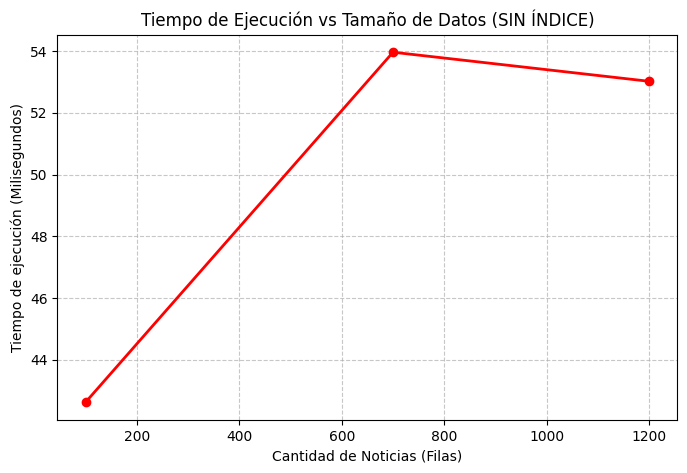

In [41]:
import time
import pandas as pd
import matplotlib.pyplot as plt

tamanos = [100, 700, 1200]
tiempos_ejecucion = []

conn = connect_db()
cursor = conn.cursor()

print("Iniciando medición de rendimiento para múltiples queries...")

for limite in tamanos:
    # Vamos a repetir el bloque entero unas 10 veces para estabilizar el promedio ya que los tiempos son bajos
    repeticiones = 10 
    
    inicio = time.time()
    
    for _ in range(repeticiones):
        for query_str in test_queries:
            tokens = query_str.split()
            sql_conditions = []
            params = []
            last_was_word = False
            
            for token in tokens:
                if token in ["AND", "OR", "AND-NOT"]:
                    if token == "AND": sql_conditions.append("AND")
                    elif token == "OR": sql_conditions.append("OR")
                    elif token == "AND-NOT": sql_conditions.append("AND NOT")
                    last_was_word = False
                else:
                    if last_was_word: sql_conditions.append("AND")
                    
                    tokens_limpios = preprocess(token)
                    token_final = tokens_limpios[0] if len(tokens_limpios) > 0 else "termino_ignorado"
                    
                    sql_conditions.append("bag_of_words ? %s")
                    params.append(token_final)
                    last_was_word = True
                    
            where_clause = " ".join(sql_conditions)
            
            sql_query = f"SELECT id FROM noticias WHERE {where_clause} LIMIT {limite};"
            
            # Ejecutar
            cursor.execute(sql_query, tuple(params))
            cursor.fetchall()
            
    fin = time.time()
    
    # Calculamos el tiempo promedio
    tiempo_promedio_ms = ((fin - inicio) / repeticiones) * 1000
    tiempos_ejecucion.append(tiempo_promedio_ms)
    print(f"Tamaño {limite} filas -> Tiempo promedio para 12 consultas: {tiempo_promedio_ms:.4f} ms")

cursor.close()
conn.close()

# Dibujar el gráfico para tu PDF
plt.figure(figsize=(8, 5))
plt.plot(tamanos, tiempos_ejecucion, marker='o', color='red', linestyle='-', linewidth=2)
plt.title('Tiempo de Ejecución vs Tamaño de Datos (SIN ÍNDICE)')
plt.xlabel('Cantidad de Noticias (Filas)')
plt.ylabel('Tiempo de ejecución (Milisegundos)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Creando índice GIN en la base de datos... (esto puede tardar un par de segundos)
¡Índice creado exitosamente!

Iniciando medición de rendimiento para múltiples queries CON ÍNDICE...
Tamaño 100 filas -> Tiempo promedio para 12 consultas: 9.8686 ms
Tamaño 700 filas -> Tiempo promedio para 12 consultas: 11.7715 ms
Tamaño 1200 filas -> Tiempo promedio para 12 consultas: 12.1927 ms


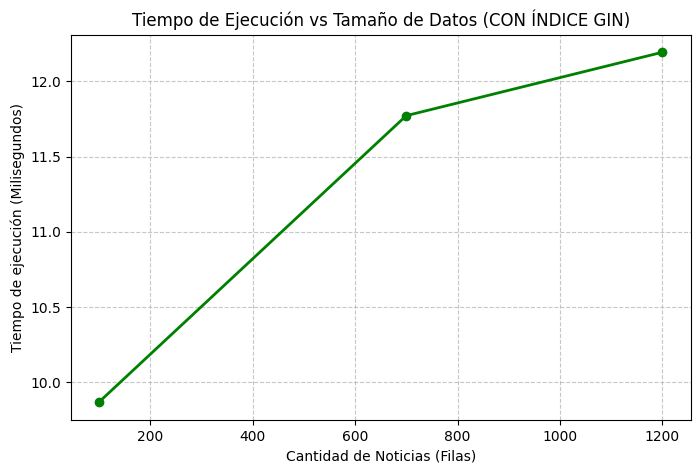

In [42]:
import time
import pandas as pd
import matplotlib.pyplot as plt

conn = connect_db()
cursor = conn.cursor()

print("Creando índice GIN en la base de datos... (esto puede tardar un par de segundos)")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_bag_of_words ON noticias USING GIN (bag_of_words);")
conn.commit()
print("¡Índice creado exitosamente!\n")

tamanos = [100, 700, 1200]
tiempos_ejecucion = []

print("Iniciando medición de rendimiento para múltiples queries CON ÍNDICE...")

for limite in tamanos:
    repeticiones = 10 
    
    inicio = time.time()
    
    for _ in range(repeticiones):
        for query_str in test_queries:
            tokens = query_str.split()
            sql_conditions = []
            params = []
            last_was_word = False
            
            for token in tokens:
                if token in ["AND", "OR", "AND-NOT"]:
                    if token == "AND": sql_conditions.append("AND")
                    elif token == "OR": sql_conditions.append("OR")
                    elif token == "AND-NOT": sql_conditions.append("AND NOT")
                    last_was_word = False
                else:
                    if last_was_word: sql_conditions.append("AND")
                    
                    tokens_limpios = preprocess(token)
                    token_final = tokens_limpios[0] if len(tokens_limpios) > 0 else "termino_ignorado"
                    
                    sql_conditions.append("bag_of_words ? %s")
                    params.append(token_final)
                    last_was_word = True
                    
            where_clause = " ".join(sql_conditions)
            
            sql_query = f"SELECT id FROM noticias WHERE {where_clause} LIMIT {limite};"
            
            # Ejecutar
            cursor.execute(sql_query, tuple(params))
            cursor.fetchall()
            
    fin = time.time()
    
    tiempo_promedio_ms = ((fin - inicio) / repeticiones) * 1000
    tiempos_ejecucion.append(tiempo_promedio_ms)
    print(f"Tamaño {limite} filas -> Tiempo promedio para 12 consultas: {tiempo_promedio_ms:.4f} ms")

cursor.close()
conn.close()

# 3. GRÁFICO (Actualizado a Verde y con nuevo título)
plt.figure(figsize=(8, 5))
plt.plot(tamanos, tiempos_ejecucion, marker='o', color='green', linestyle='-', linewidth=2)
plt.title('Tiempo de Ejecución vs Tamaño de Datos (CON ÍNDICE GIN)')
plt.xlabel('Cantidad de Noticias (Filas)')
plt.ylabel('Tiempo de ejecución (Milisegundos)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()